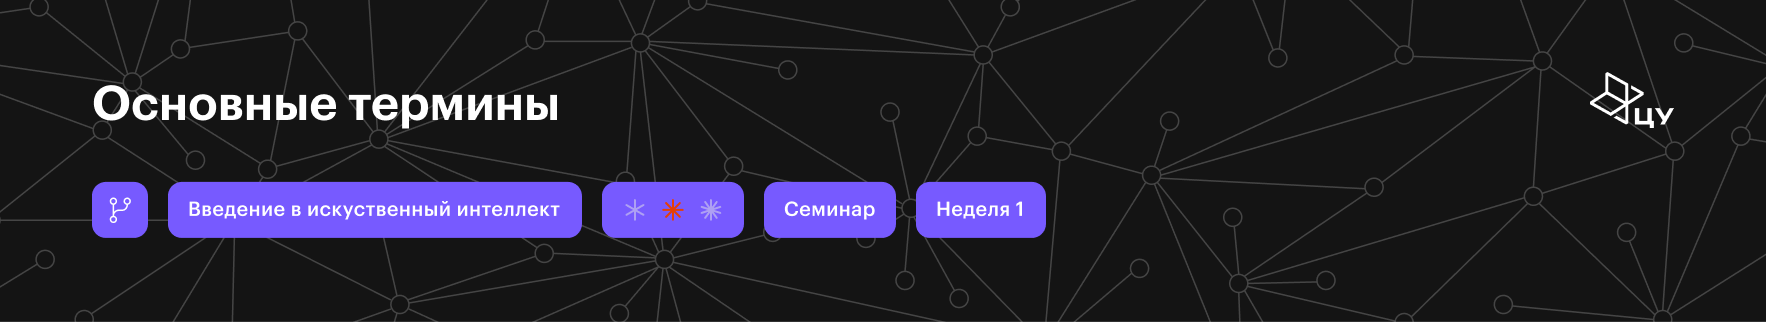

# Семинар по теме «Основные термины»

Сегодня ты сделаешь первый шаг в мир машинного обучения.

Из этого семинара ты узнаешь:

- что такое регрессия, и какую константу можно использовать в качестве модели;
- зачем нужны функции MAE и MSE, в чём их различия;
- как работать с `pandas` и `seaborn`, а также обрабатывать пропуски в данных.



## Константная модель



### Постановка задачи регрессии

Решим задачу. Клиенту страховой компании нужно предсказать стоимость страховки. При этом есть данные о прошлых клиентах:
- возраст;
- пол;
- курит ли человек;
- регион;
- стоимость их страховки.

Задачу такого типа, в которой нужно предсказать число, называют **задачей регрессии**.

Формально есть данные:

$$(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n),$$

- где $x_i$ &mdash; признаки клиента, например, возраст, пол и другие;
- $y_i$ &mdash; то, что мы хотим предсказывать (стоимость страховки).

Нужно найти такую функцию $a(x)$, чтобы её предсказания $a(x_i)$ были как можно ближе к настоящим $y_i$.

### Подход без модели

Перед построением сложных моделей зададимся простым вопросом:

> что, если мы будем предсказывать всем клиентам одно и то же число (константу $c$) и вообще не смотреть на его признаки? Какую константу тогда выбрать?

Такой подход называется **константной моделью**. Она понадобится нам как baseline, чтобы сравнивать с ней все умные модели.

Здесь возникает вопрос: если умная модель работает хуже константы, то нужна ли она вообще?




Чтобы узнать, почему такие модели важны, найдём ответы на два вопроса.

1. Пусть наша модель с вероятностью 95% угадывает, изображена на картинке кошечка, а не собачка. Насколько это хорошее качество?
2. Что тогда будет базовым уровнем (baseline)?

In [51]:
# Твой ответ

#### Поиск лучшей константы

Чтобы выбрать «лучшую» константу — договоримся, что именно значит лучшая. В этом поможет функция потерь — она покажет, насколько хорошо мы предсказываем стоимость страховки.

Функция потерь работает так.
1. Принимает на вход реальные ответы $y_i$ и наши предсказания $\hat{y}_i$.
2. Возвращает одно число. Чем это число меньше, тем лучше наши предсказания.

Именно функцию потерь мы и будем минимизировать при поиске оптимальной константы. А ещё когда позже будем обучать настоящие модели.

К двум самым распространённым функциям потерь относят MAE и MSE. Их же часто используют и как метрики качества — для итогового сравнения разных моделей между собой. Это очень удобно: если мы обучали модель, минимизируя MSE, то сравнивать с baseline её можно по той же MSE.

### Метрики MAE и MSE



Обозначим настоящий ответ как $y_i$, а наше предсказание как $\hat{y}_i$ (а в случае константы $\hat{y}_i = c$).

>**MAE** (Mean Absolute Error) &mdash; средняя абсолютная ошибка:
>
>$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|.$$

>**MSE** (Mean Squared Error) &mdash; средняя квадратичная ошибка:
>
>$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2.$$

Исследуем, на что влияет разница между этими двумя функциями потерь.

### Задание 1

Есть 5 клиентов, для которых мы точно знаем стоимость страховки в тысячах долларов.

| Клиент  | 1 | 2 | 3 | 4 | 5  |
|---------|---|---|---|---|----|
| Стоимость | 3 | 5 | 7 | 9 | 40 |

На основе этих данных мы хотим обучить константную модель, которая любому клиенту предскажет число $c$. Для этого нужно ответить на два вопроса.
- Какое $c$ минимизирует MSE?  
- Какое $c$ минимизирует MAE?

Проверь две гипотезы.
1. $c$ — это среднее.
2. $c$ — это медиана.




#### Считаем среднее и медиану

In [60]:
# Напиши код здесь
import numpy as np

y = np.array([3, 5, 7, 9, 40])

mean_y = np.mean(y)
median_y = np.median(y)

print(f"Среднее: {mean_y}")
print(f"Медиана: {median_y}")

Среднее: 12.8
Медиана: 7.0


Среднее «уехало» вправо из-за выброса 40. Медиана осталась в центре.



#### Теперь посчитаем MAE и MSE для обеих констант.

In [58]:
def mse(y, c):
  return np.mean((y - c)**2)
def mae(y, c):
  return np.mean(np.abs(y - c))



print(f"MSE(c = среднее = {mean_y}): {mse(y, mean_y):.2f}")
print(f"MSE(c = медиана = {median_y}): {mse(y, median_y):.2f}")
print()
print(f"MAE(c = среднее = {mean_y}): {mae(y, mean_y):.2f}")
print(f"MAE(c = медиана = {median_y}): {mae(y, median_y):.2f}")

MSE(c = среднее = 12.8): 188.96
MSE(c = медиана = 7.0): 222.60

MAE(c = среднее = 12.8): 10.88
MAE(c = медиана = 7.0): 8.20


### Разбор результата

#### MSE

Хотим найти $c$, минимизирующий:

$$L(c) = \frac{1}{n}\sum_{i=1}^{n}(y_i - c)^2.$$

Функция гладкая, берём производную и приравниваем к нулю:

$$\frac{dL}{dc} = -\frac{2}{n}\sum_{i=1}^{n}(y_i - c) = 0;$$

$$\sum_{i=1}^{n} y_i = n \cdot c \quad \Rightarrow \quad c^* = \frac{1}{n}\sum_{i=1}^{n} y_i = \bar{y}.$$

**Вывод.** Поэтому оптимум MSE &mdash; среднее.

#### MAE

MAE-производную взять сложнее (модуль не гладкий в нуле), но есть простое рассуждение. Представим, что $c$ стоит на числовой прямой, а точки $y_i$ разбросаны вокруг. Если мы чуть-чуть сдвинем $c$ вправо на $\delta$, то:

- расстояние до точек справа от $c$ — уменьшится на $\delta$ (для каждой точки);
- расстояние до точек слева от $c$ — увеличится на $\delta$ (для каждой точки).

Чтобы движение перестало улучшать сумму, нужно, чтобы точек слева и справа было поровну. А это и есть определение медианы.

**Вывод.** Поэтому оптимум MAE &mdash; медиана.

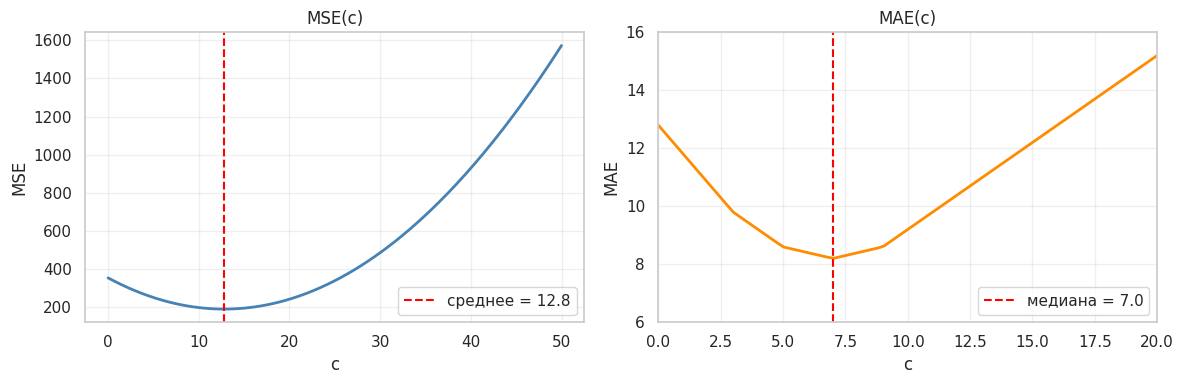

In [ ]:
#@title Визуализация (служебный код)

# Переберём разные константы и построим график (просто запустить код)
import matplotlib.pyplot as plt

candidates = np.linspace(0, 50, 200)
mse_values = [mse(y, c) for c in candidates]
mae_values = [mae(y, c) for c in candidates]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(candidates, mse_values, color='steelblue', linewidth=2)
axes[0].axvline(mean_y, color='red', linestyle='--', label=f'среднее = {mean_y}')
axes[0].set_title('MSE(c)')
axes[0].set_xlabel('c')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(candidates, mae_values, color='darkorange', linewidth=2)
axes[1].axvline(median_y, color='red', linestyle='--', label=f'медиана = {median_y}')
axes[1].set_title('MAE(c)')
axes[1].set_xlabel('c')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 20)
axes[1].set_ylim(6, 16)

plt.tight_layout()
plt.show()

График MSE &mdash; гладкая парабола с минимумом в среднем. Минимум MAE &mdash; в медиане, и он «острый»: слева и справа от медианы функция линейная.

### Задание 2


Ответь на вопросы.

1. Какая функция сильнее наказывает за один большой промах — MAE или MSE?
2. Что произойдёт, если в наших данных вместо 40 будет 1000? Как изменятся оптимальные $c$ для MSE и MAE?
3. Если изредка к нам заходят очень состоятельные клиенты и особенно большие значения &mdash; это тоже реальная стоимость? Какую метрику в этом случае разумнее использовать?

In [ ]:
# Твой ответ

### Итог первой части

| Функция | Оптимальная константа | Устойчивость к выбросам | Дифференцируемость |
|---------|-----------------------|--------------------------| --------|
| MSE     |  Среднее $\bar{y}$ |  Нет | Да, везде
| MAE     |  Медиана $\text{M}(y)$ |  Да | Нет, в 0 из-за модуля

>Запомним: **константная модель — это самый простой baseline**. Далее мы будем строить более сложные модели, а к этому варианту вернёмся в конце семинара, чтобы понять, действительно ли наша обученная модель научилась чему-то полезному.

## Подготовка данных

<!--## Знакомство с реальными данными-->

Перейдём к реальному датасету. Для этого будем работать с датасетом [**Insurance**](https://www.kaggle.com/datasets/mirichoi0218/insurance), в котором есть данные по медицинской страховке в США.

### Загрузка данных

In [61]:
!gdown 17H_g6D6Y9s20szMPOfY7cq8xVwEw31ro

Downloading...
From: https://drive.google.com/uc?id=17H_g6D6Y9s20szMPOfY7cq8xVwEw31ro
To: /content/insurance_mod.csv
100% 71.6k/71.6k [00:00<00:00, 45.4MB/s]


In [62]:
# Библиотеки для работы с табличными данными
import pandas as pd
import numpy as np

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [63]:
df = pd.read_csv('/content/insurance_mod.csv')
df.drop('charges_euro', axis=1, inplace=True)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Что видно в таблице

- В строках записаны наблюдения для одного клиента.
- В столбцах &mdash; признаки:
  - `age` &mdash; возраст;
  - `sex` &mdash; пол (`male` / `female`);
  - `bmi` &mdash; индекс массы тела;
  - `children` &mdash; число детей;
  - `smoker` &mdash; курит ли клиент (`yes` / `no`);
  - `region` &mdash; регион;
  - `charges` &mdash; целевая переменная, стоимость страховки в долларах.

Наша задача &mdash; предсказать `charges` по остальным признакам.

## Знакомство с реальными данными

### Задание 3

<!--### Задание 2.1-->

В описании датасета указано, что все столбцы, которые отображаются как `object`, должны быть строками.

Проверь это — выведи типы данных всех столбцов с типом `object`.


In [67]:
df.info()

print(type(df.iloc[0,1]))
print(type(df.iloc[0,4]))
print(type(df.iloc[0,5]))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
<class 'str'>
<class 'str'>
<class 'str'>


### Задание 4

Используй метод `.info()` и посмотри общую информацию о датасете:
- сколько строк;
- какие типы данных;
- где есть пропуски.

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Вопрос

Что тут можно увидеть? Сделай выводы.

### Задание 5

<!--### Задание 2.3-->

Внеси в датасет данные о дедушке из Америки. Его данные:

- 74 года;
- имеет троих детей;
- курит сигары;
- страховка обошлась ему в 1500 долларов.

In [69]:
# Напиши код здесь

new_data = {"age" : 74, "sex" : "male", "bmi" : np.nan, "children" : 3, "smoker" : "yes", "charges" : 1500}

df.loc[len(df)] = new_data

In [70]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603
1338,74,male,NaN,3,yes,NaN,1500.0000


### Задание 6

Вычисли основные статистики для числовых и категориальных признаков.

In [72]:
df.describe()

,age,bmi,children,charges
count,1339.000000,1338.000000,1339.000000,1339.000000
mean,39.233010,30.663397,1.096341,13261.631808
std,14.076858,6.098187,1.206166,12109.757796
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4729.002375
50%,39.000000,30.400000,1.000000,9377.904700
75%,51.000000,34.693750,2.000000,16622.107580
max,74.000000,53.130000,5.000000,63770.428010


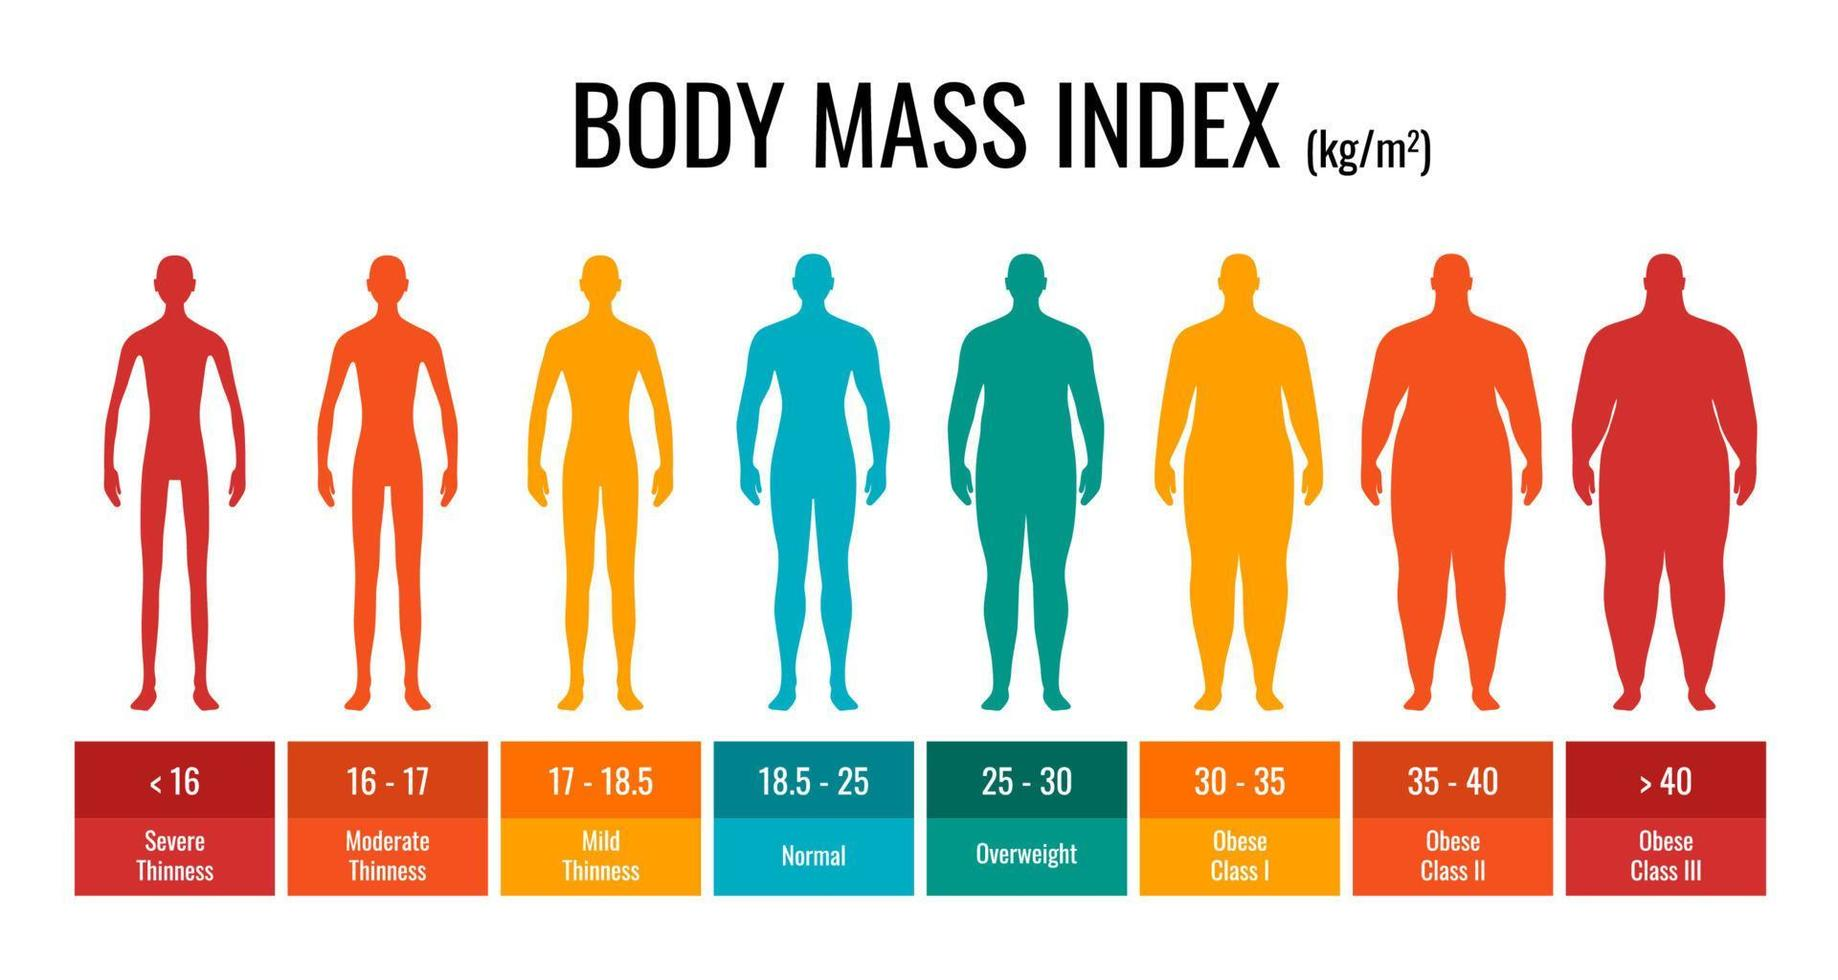

In [73]:
df.describe(include="object")

,sex,smoker,region
count,1339,1339,1338
unique,2,2,4
top,male,no,southeast
freq,677,1064,364


### Вопрос

Что интересного можно узнать из этих таблиц?

In [ ]:
# Твой ответ

## EDA — разведочный анализ данных



По сравнению с таблицами, графики — это более удобный инструмент для восприятия информации. Поэтому используем графики для анализа распределения признаков.

### Разделим признаки на числовые и категориальные


In [74]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Числовые признаки:", numerical_cols)
print("Категориальные:", categorical_cols)

Числовые признаки: ['age', 'bmi', 'children', 'charges']
Категориальные: ['sex', 'smoker', 'region']


### Используем гистограммы числовых признаков

Гистограмма показывает распределение значений признака — как часто встречается каждое из значений.

В `seaborn` для этого есть `histplot`. Он не только строит гистограмму, но и умеет добавить сверху **KDE** (Kernel Density Estimate) — сглаженную оценку плотности.

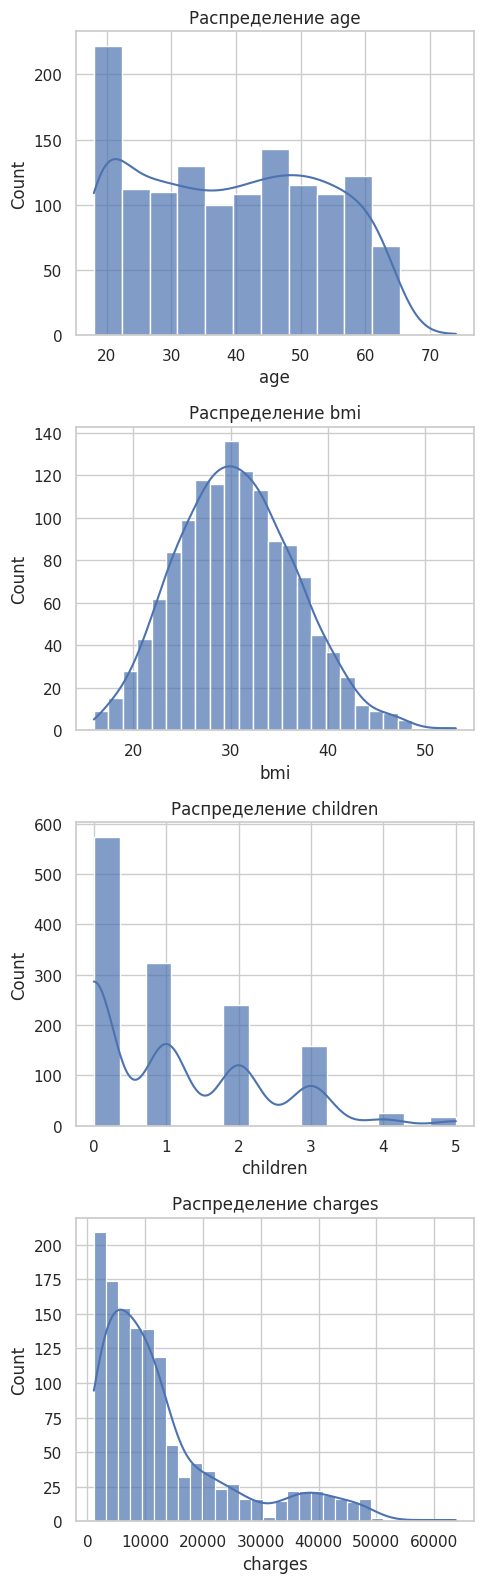

In [ ]:
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(5, 4*len(numerical_cols)))

for ax, col in zip(axes, numerical_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax, alpha=0.7)
    ax.set_title(f'Распределение {col}')

plt.tight_layout()
plt.show()

### Задание 7

Рассмотри гистограммы. Ответь на вопросы.

- Какие распределения симметричны, а какие со «скошенным хвостом»?
- Какие распределения имеют явные выбросы?
- Что с целевым признаком `charges`? Как он себя ведёт?

In [ ]:
# Твой ответ

### Категориальные признаки

Для них гистограмма не годится — нужен `countplot`, который показывает число объектов в каждой категории.

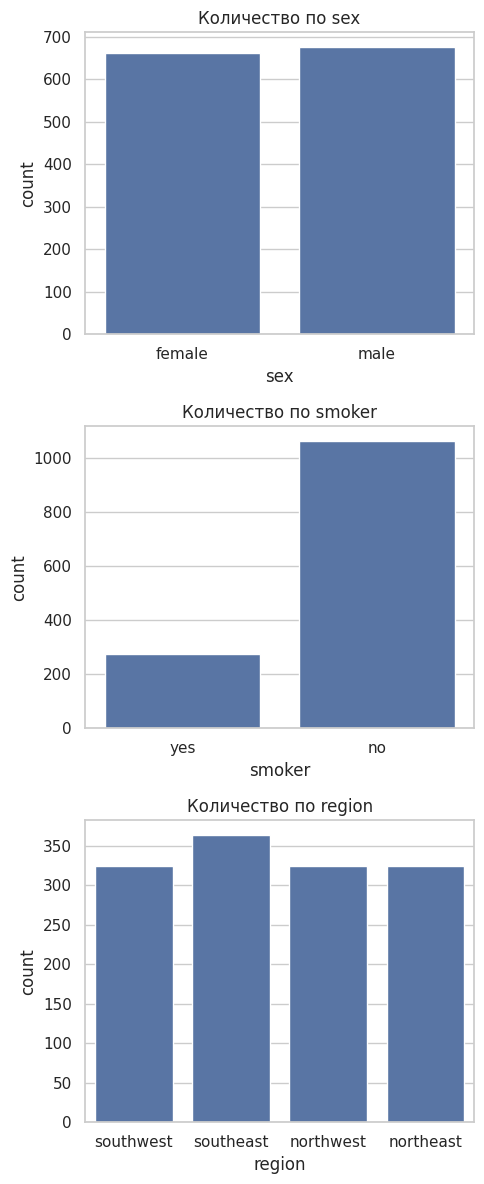

In [ ]:
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(5, 4*len(categorical_cols)))

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f'Количество по {col}')

plt.tight_layout()
plt.show()

Что видно на гистограмме:

- `sex` — почти 50/50;
- `smoker` — курильщиков сильно меньше (~20%);
- `region` — четыре региона примерно поровну.

### Парные распределения — `pairplot`

`sns.pairplot()` помогает получить всё сразу:
- гистограммы по диагонали;
- scatterplot для каждой пары признаков.

Более того, мы можем раскрасить точки по категориальному признаку через параметр `hue`. Используем его и раскрасим по категориальному признаку `smoker` — это самый интересный признак с точки зрения стоимости страховки.

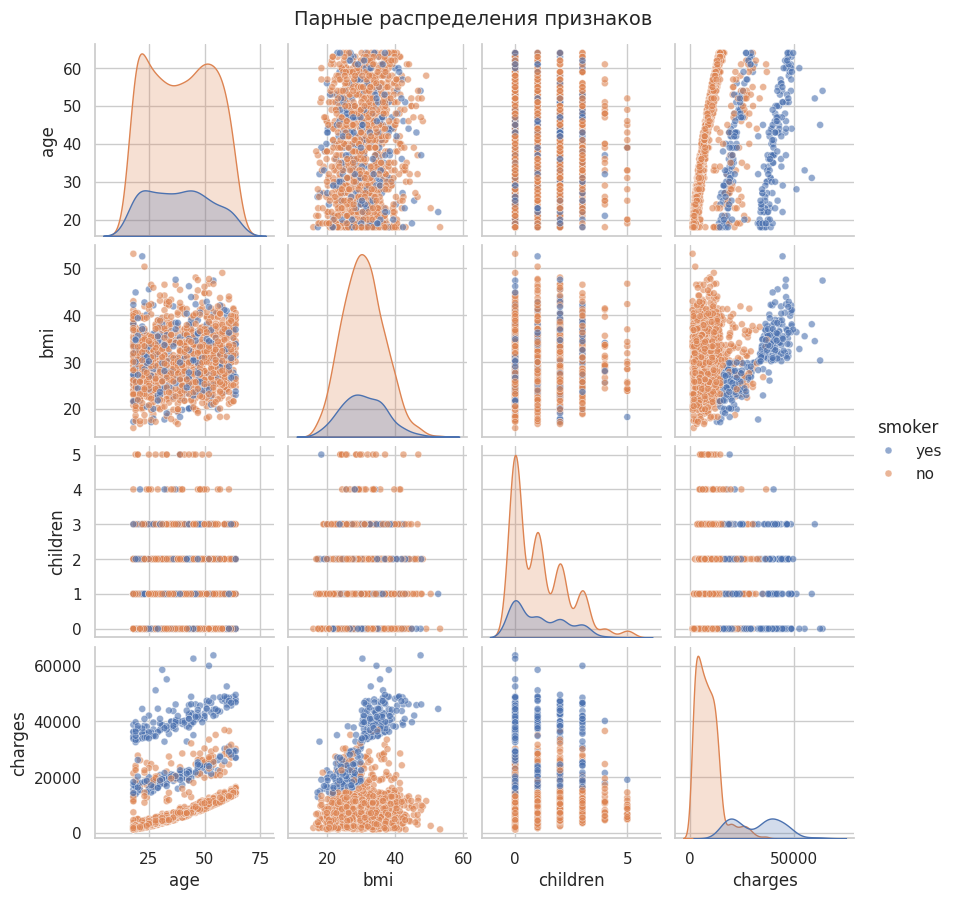

In [ ]:
# Берём числовые признаки + smoker для раскраски
cols_for_pairplot = ['age', 'bmi', 'children', 'charges', 'smoker']

sns.pairplot(
    df[cols_for_pairplot].dropna(),
    hue='smoker',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 25},
    height=2.2
)
plt.suptitle('Парные распределения признаков', y=1.02, fontsize=14)
plt.show()

### Задание 8

Рассмотри пары `(age, charges)` и `(bmi, charges)`, раскрашенные по `smoker`.

Ответь на вопрос: что бросается в глаза?

In [ ]:
# Твой ответ

## Обработка данных

Прежде чем загружать данные в модель, нужно привести их в порядок. Здесь возникают две главные проблемы.

1. Пропуски — `NaN` в ячейках.
2. Категориальные признаки — модели умеют работать только с числами.

### Пропуски

Проверим, где именно есть пропуски и сколько их.

In [75]:
df.isna().sum()

,0
age,0
sex,0
bmi,1
children,0
smoker,0
region,1
charges,0


Пропусков немного, но они есть в `bmi` и `region`. Возникает вопрос: что с ними делать?

Варианты решения.

1. Удалить строки с `NaN` (`df.dropna()`). Так мы потеряем данные.
2. Заполнить средним/медианой — для числовых, или самой частой категорией — для категориальных. Это поможет не потерять строки, но добавит немного шума.

### Задание 9

<!--- Задание 4.1-->


Заполни пропуски:
- в `bmi` — медианой (потому что она устойчивее к выбросам);
- в `region` — самой частой категорией (модой).

In [79]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())
df["region"] = df["region"].fillna(df["region"].mode()[0])


In [80]:
# Убедимся, что пропусков больше нет
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### Категориальные признаки

`sex`, `smoker` и `region` — это строки, поэтому модель не сможет с ними работать. Чтобы исправить это, нужно превратить их в числа.

Самый распространённый способ — использовать One-Hot Encoding (OHE). Для этого по каждой уникальной категории создаём отдельный бинарный столбец:
- если объект относится к этой категории — 1;
- иначе — 0.

В pandas это делают двумя способами:
- одной командой — `pd.get_dummies()`;
- или с помощью `OneHotEncoder` из `sklearn.preprocessing`.


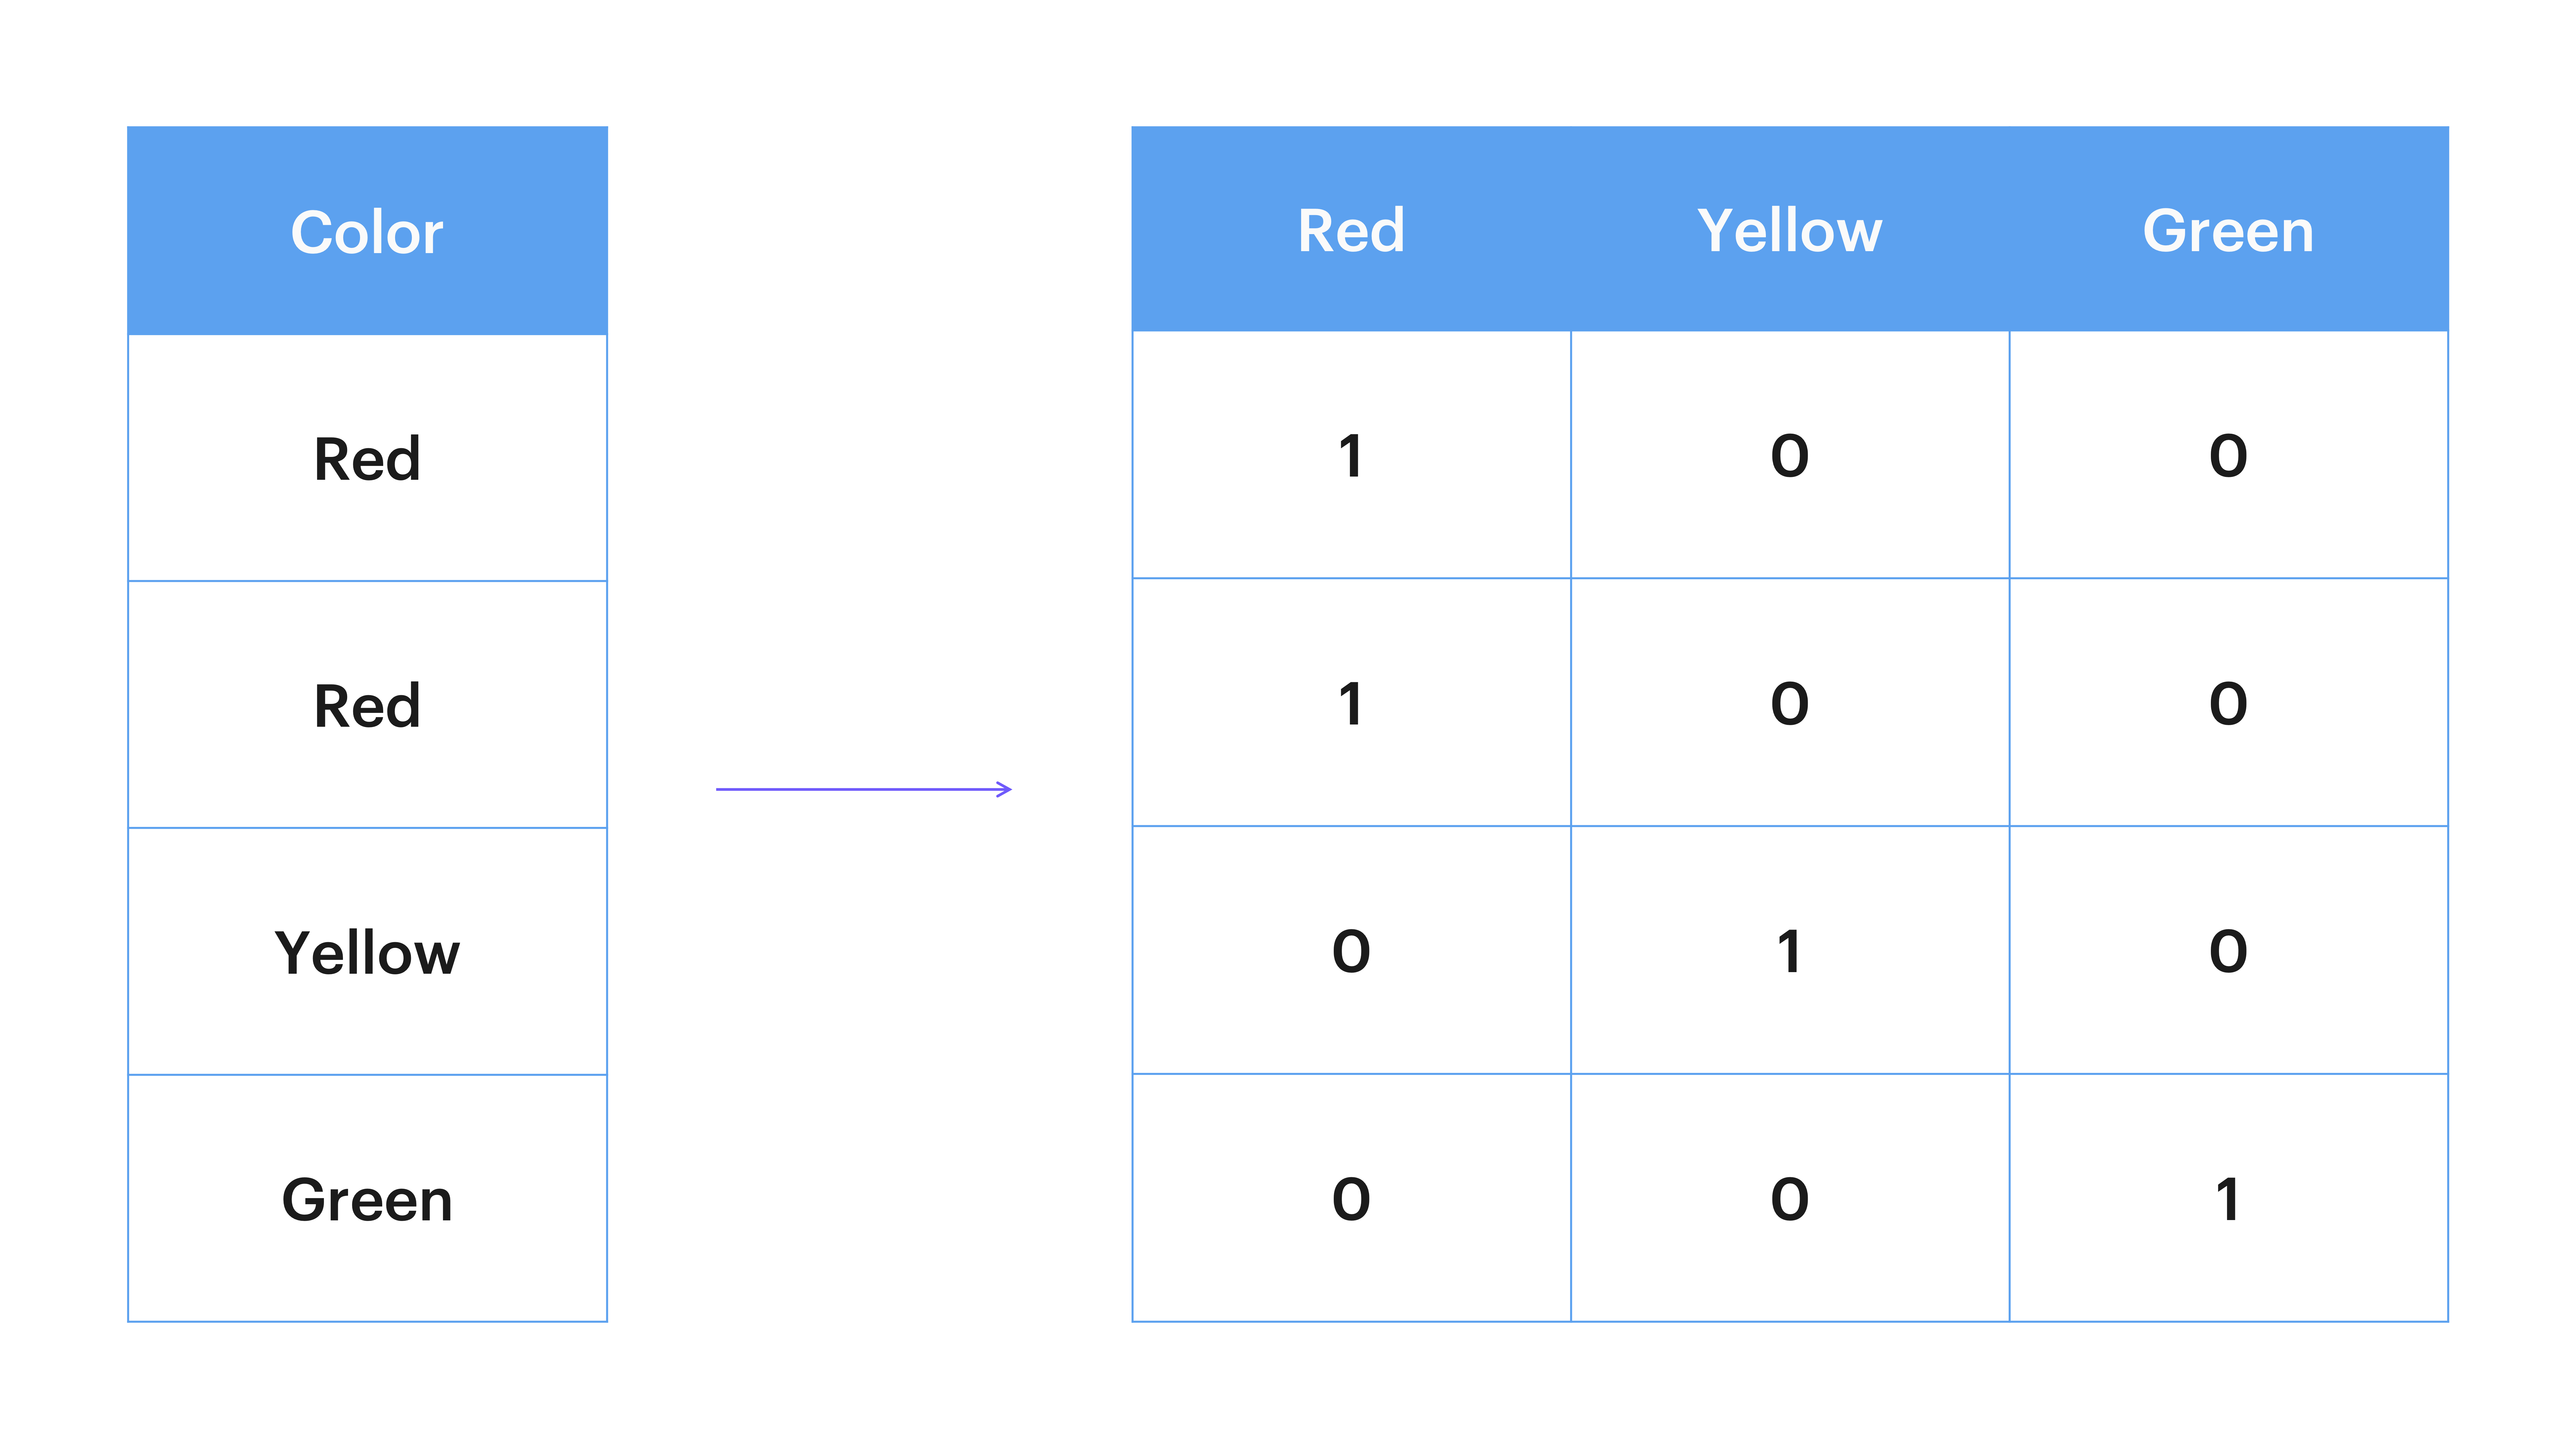
*Рисунок 1. Как работает One-Hot Encoding*

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True  # См. комментарий ниже
)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Что делает `drop_first=True`.

Параметр удаляет один из бинарных столбцов для каждого признака. Если у пола две категории и мы знаем, что `sex_male = 0`, то это автоматически означает, что пол человека — женский. Поэтому второй столбец не нужен.

Так, для признака `region` из 4 столбцов останется 3.

### Другие способы кодирования

Кроме OHE, есть и другие способы кодирования. Разберём их работу.

- **Label Encoding** — каждой категории присваивают число (0, 1, 2, 3). Но тут есть нюанс: это может внести ложный порядок. А именно модель может решить, что «регион 3» больше «региона 1». При этом метод хорошо подходит для порядковых признаков (например, «начальное/среднее/высшее образование»). Из плюсов: Label Encoding не раздувает число признаков — один столбец остаётся одним столбцом.
- **Ordinal Encoding** — это тот же Label Encoding, только сразу для нескольких столбцов и с возможностью задать явный порядок категорий.
- **Target Encoding** — каждую категорию заменяют средним значением таргета в этой категории. Подход не раздувает число признаков и хорошо улавливает реальную связь категории с таргетом, особенно когда категорий много. Но с другой стороны, легко приводит к утечке данных. Если же считать среднее по всей выборке, то информация о таргете попадает в признаки.

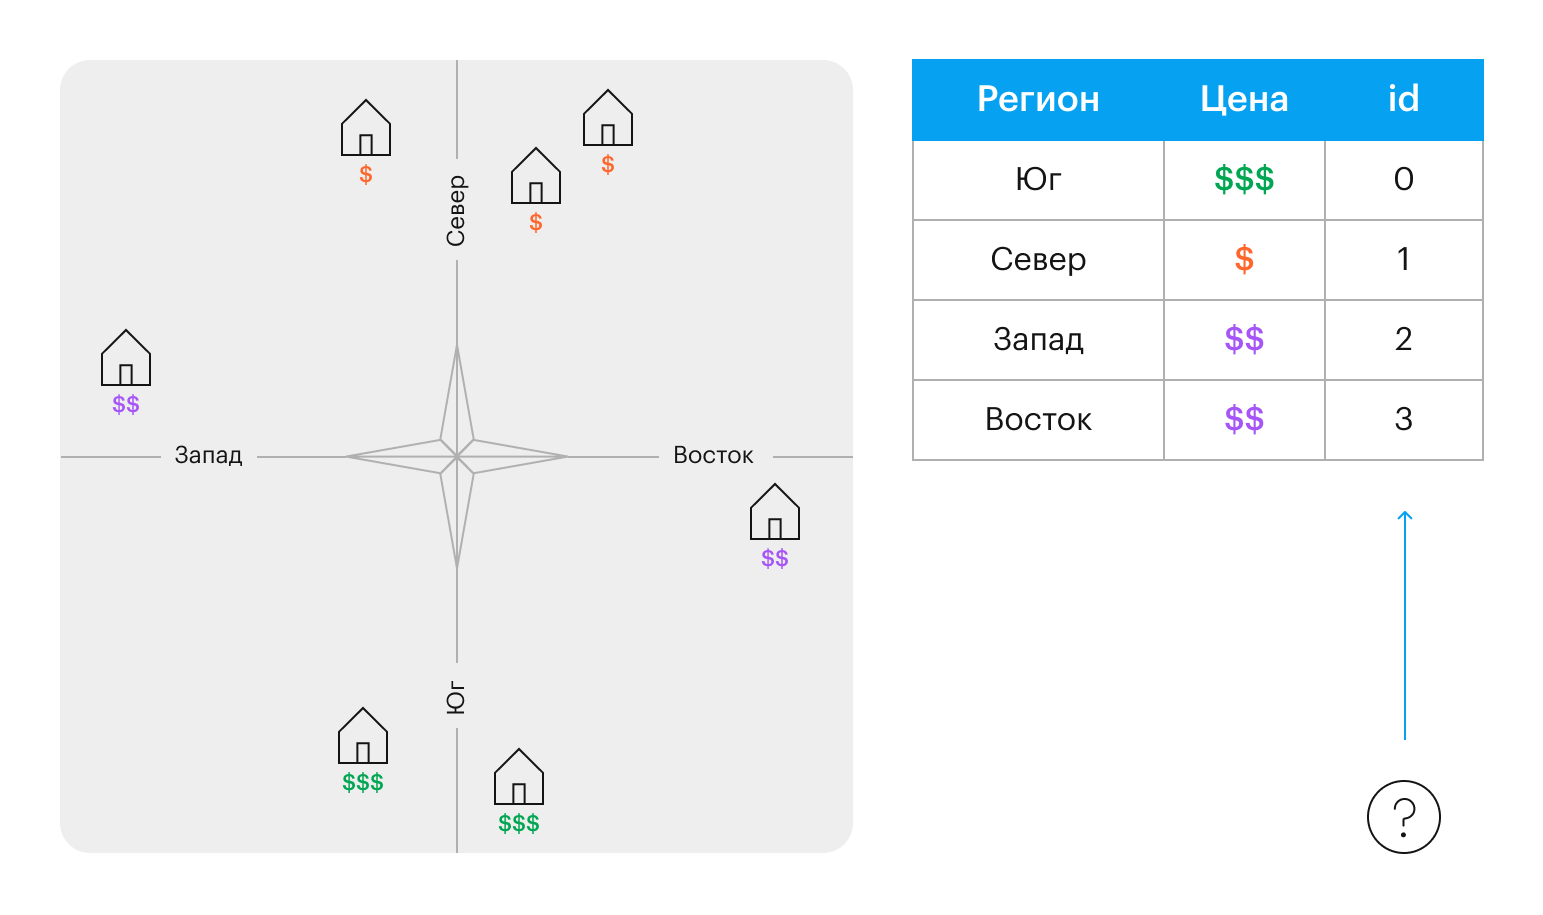
*Рисунок 2. Пример Label Encoding*

<!--- **Target Encoding** — каждую категорию заменяют средним значением таргета в этой категории. Не раздувает число признаков и хорошо улавливает реальную связь категории с таргетом, особенно когда категорий много. Но с другой стороны, легко приводит к утечке данных. Если считать среднее по всей выборке, то информация о таргете попадает в признаки.-->

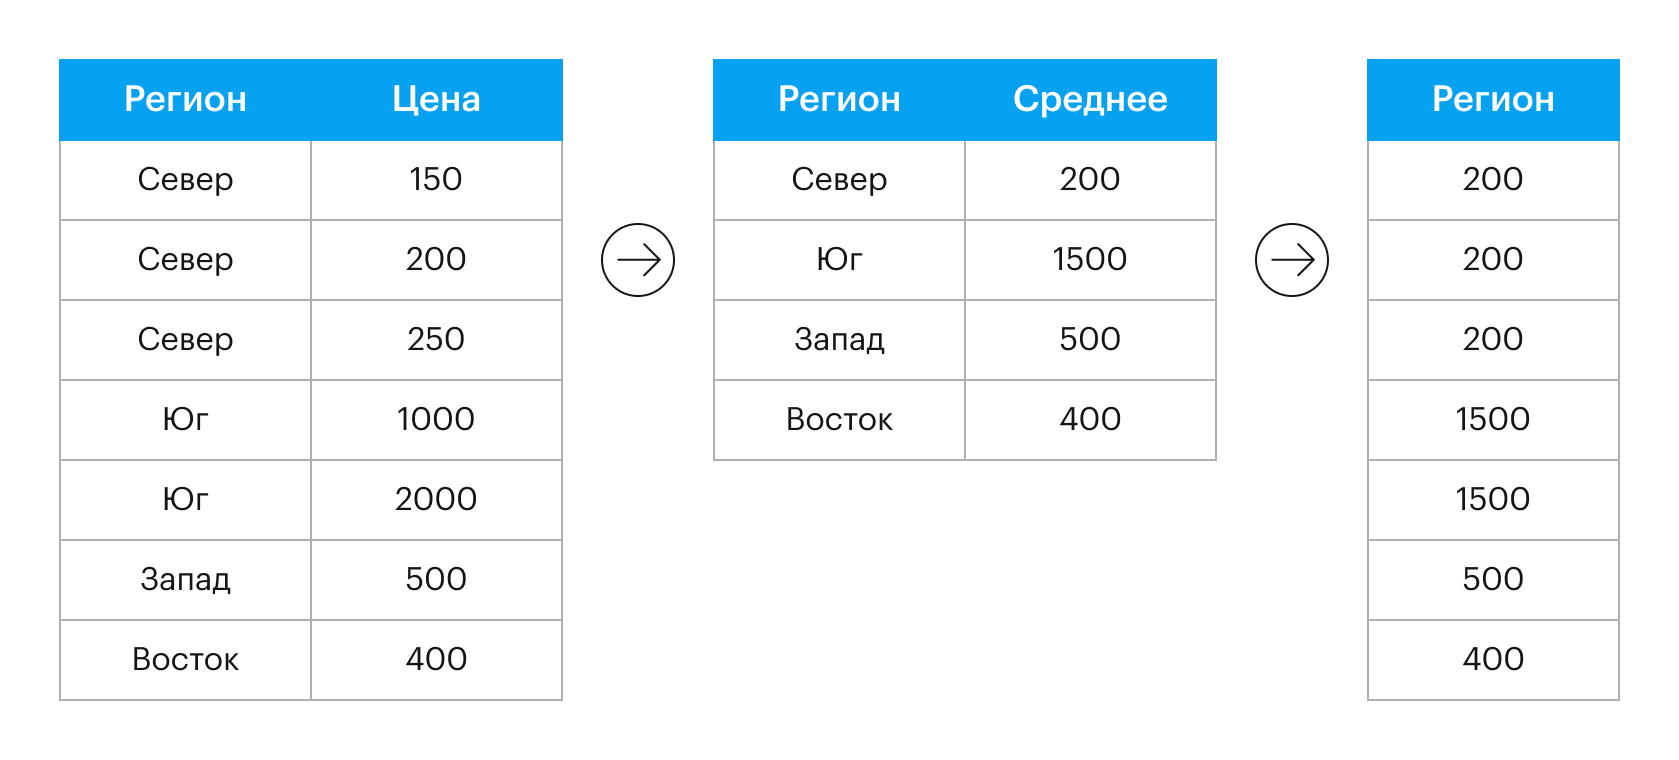
*Рисунок 3. Пример работы Target Encoding*

## Стандартизация и нормализация

Снова взглянем на признаки:

- `age` — от 18 до 64;
- `bmi` — от ~16 до ~53;
- `children` — от 0 до 5;
- `sex_male`, `smoker_yes`, `region_*` — 0 или 1.

Все они живут в разных масштабах: *в десятках, единицах и даже в двоичной системе*. И для многих моделей — это большая проблема. Разберём, почему так происходит.

Модель — это функция из распределения в распределение. Чтобы модель не считала одни признаки важнее других, данные должны быть одинаково устроены — однообразны. Это поможет сделать все признаки равноправными — так, чтобы модель могла правильно оценить их реальный вклад.


*Разберём два главных подхода, которые приводят данные к однообразию, — стандартизацию и нормализацию.*

>**Стандартизация (StandardScaler)** — вычитаем среднее, делим на стандартное отклонение:
>
>$$x_{\text{new}} = \frac{x - \mu}{\sigma}.$$

После стандартизации у признака:
- среднее — 0;
- стандартное отклонение — 1;
- диапазон не ограничен: после преобразования можем получить любые максимум и минимум.

>**Нормализация MinMax (MinMaxScaler)** — растягиваем или сжимаем признак в отрезок $[0, 1]$:
>
>$$x_{\text{new}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}.$$
>
>В итоге получим диапазон ровно $[0, 1]$.

### Пример стандартизации и нормализации MinMax

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Возьмём для наглядности только числовые признаки
X_demo = df_encoded[['age', 'bmi', 'children', 'charges']].copy()

# Стандартизация
std_scaler = StandardScaler()
X_std = pd.DataFrame(
    std_scaler.fit_transform(X_demo),
    columns=X_demo.columns
)

# MinMax
mm_scaler = MinMaxScaler()
X_mm = pd.DataFrame(
    mm_scaler.fit_transform(X_demo),
    columns=X_demo.columns
)

# Сводная статистика
print("До масштабирования:")
display(X_demo.describe().loc[['mean', 'std', 'min', 'max']].round(2))
print("\nПосле StandardScaler:")
display(X_std.describe().loc[['mean', 'std', 'min', 'max']].round(2))
print("\nПосле MinMaxScaler:")
display(X_mm.describe().loc[['mean', 'std', 'min', 'max']].round(2))

До масштабирования:


,age,bmi,children,charges
mean,39.23,30.66,1.10,13261.63
std,14.08,6.10,1.21,12109.76
min,18.00,15.96,0.00,1121.87
max,74.00,53.13,5.00,63770.43



После StandardScaler:


,age,bmi,children,charges
mean,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.51,-2.41,-0.91,-1.00
max,2.47,3.69,3.24,4.17



После MinMaxScaler:


,age,bmi,children,charges
mean,0.38,0.40,0.22,0.19
std,0.25,0.16,0.24,0.19
min,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00


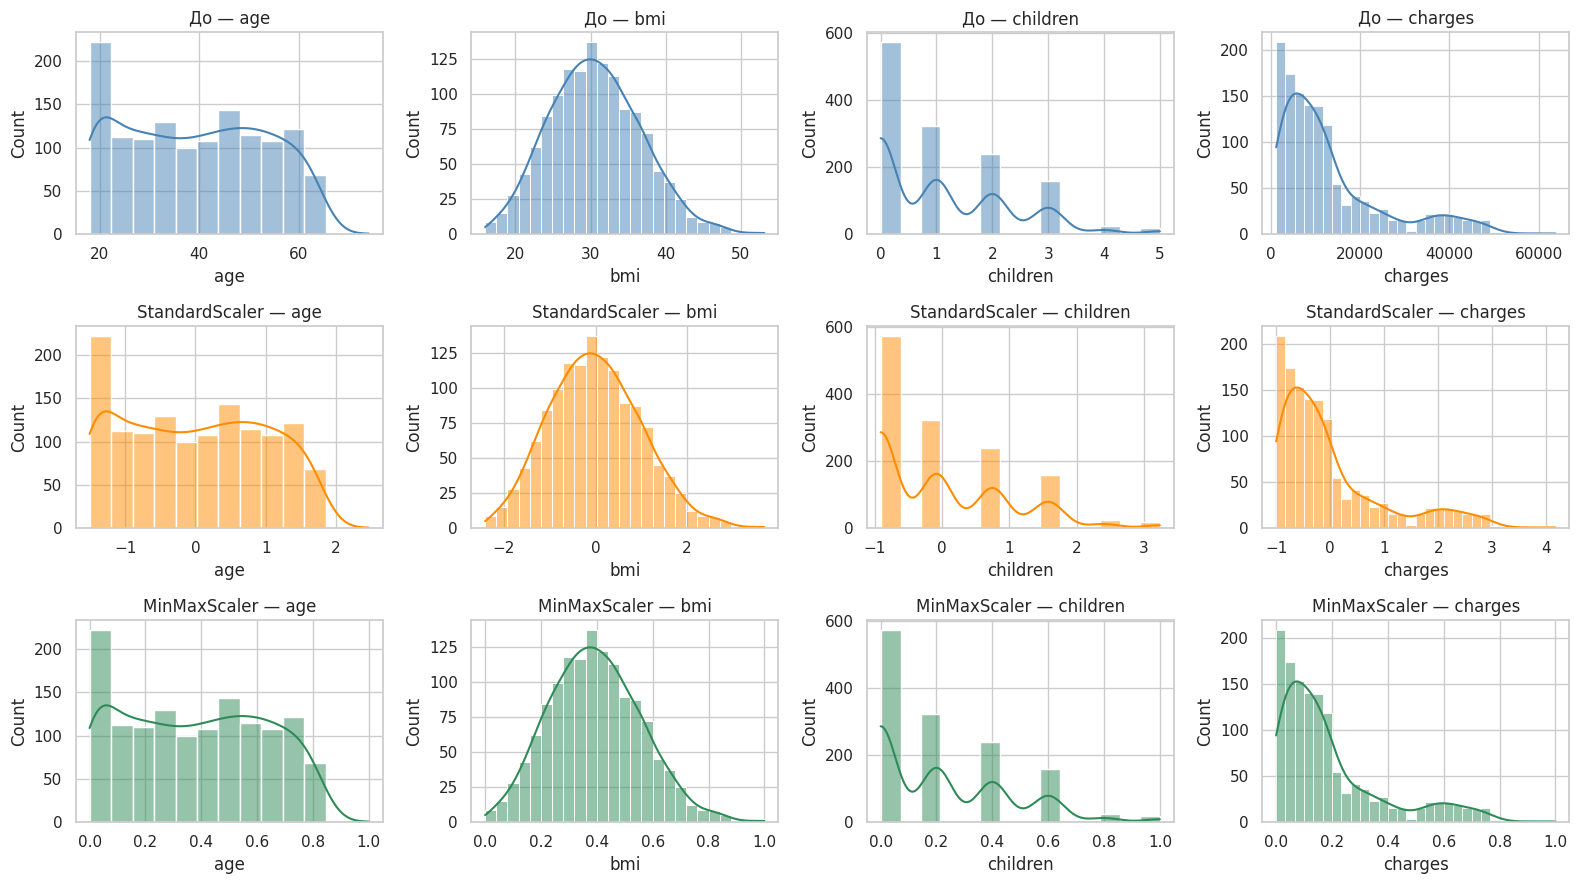

In [ ]:
#@title Визуализация: как это меняет распределения (служебный код)

fig, axes = plt.subplots(3, 4, figsize=(16, 9))

for j, col in enumerate(X_demo.columns):
    sns.histplot(X_demo[col],  ax=axes[0, j], color='steelblue',   kde=True)
    axes[0, j].set_title(f'До — {col}')

    sns.histplot(X_std[col],   ax=axes[1, j], color='darkorange', kde=True)
    axes[1, j].set_title(f'StandardScaler — {col}')

    sns.histplot(X_mm[col],    ax=axes[2, j], color='seagreen',    kde=True)
    axes[2, j].set_title(f'MinMaxScaler — {col}')

plt.tight_layout()
plt.show()

Обрати внимание:

- форма распределения не меняется ни от StandardScaler, ни от MinMaxScaler. Меняется только масштаб и центр;
- если исходное распределение было скошенным (например, `charges`) — оно останется скошенным после обоих преобразований.

## Обучаем модель и оцениваем качество



Теперь у нас есть всё, чтобы обучить первую модель. Для этого проведём:

- exploratory data analysis — разведывательный анализ данных, EDA, то есть изучим данные;
- предобработку — заполним пропуски, закодируем категории;
- масштабирование — приведём признаки к сравнимому масштабу;
- baseline — обучим константную модель (то есть подберём $c$), с которой будем сравнивать нашу модель;
- обучение модели;
- оценку качества — сравним модель с baseline.


Согласно плану, шаги 1–2 мы уже сделали. *Поэтому начнём с этапа 3.*

>**Примечание.** В будущем этот пайплайн несколько поменяется, чтобы стать в полной мере классическим пайплайном машинного обучения. Но изменения будут небольшими: каждый описанный этап важен в любом случае.


In [ ]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

### Шаг 3. Масштабирование

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

X_scaled.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.437861,-0.453457,-0.909286,-1.011266,1.967000,-0.566139,-0.612163,1.766352
1,-1.508926,0.509843,-0.079903,0.988860,-0.508388,-0.566139,1.633552,-0.566139
2,-0.798275,0.383482,1.578862,0.988860,-0.508388,-0.566139,1.633552,-0.566139
3,-0.442950,-1.305986,-0.909286,0.988860,-0.508388,1.766352,-0.612163,-0.566139
4,-0.514015,-0.292633,-0.909286,0.988860,-0.508388,1.766352,-0.612163,-0.566139


### Шаг 4. Baseline

Оптимальная константа для MSE — это среднее. Посчитаем baseline.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Константная модель = среднее
baseline_const = y.mean()

baseline_pred = np.full(shape=y.shape, fill_value=baseline_const)

# Считаем ошибки
baseline_mse = mean_squared_error(y, baseline_pred)
baseline_mae = mean_absolute_error(y, baseline_pred)

print(f"Константа (среднее): {baseline_const:.2f}")
print(f"Baseline MSE:  {baseline_mse:.2f}")
print(f"Baseline RMSE: {np.sqrt(baseline_mse):.2f}")
print(f"Baseline MAE:  {baseline_mae:.2f}")

Константа (среднее): 13261.63
Baseline MSE:  146536714.67
Baseline RMSE: 12105.24
Baseline MAE:  9089.85


**Как читать результат.** Если мы предскажем всем клиентам $≈$ $13261$, то в среднем будем ошибаться на ~$9089$ (MAE) или ~$12105$ (RMSE) на клиента. Здесь RMSE больше, потому что она чувствительна к дорогим выбросам.

Задача хорошей модели — сделать эти ошибки меньше.

### Шаг 6. Обучение модели

Линейная регрессия — это модель вида:

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_d x_d,$$

где $w_i$ — веса, которые модель находит из данных.

Пока не будем вдаваться в подробности её работы и просто применим готовую реализацию из `sklearn`.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_scaled, y)

# Предсказания
y_pred = model.predict(X_scaled)

# Ошибки на трейне
model_mse = mean_squared_error(y, y_pred)
model_mae = mean_absolute_error(y, y_pred)

print(f"LinearRegression MSE:  {model_mse:.2f}")
print(f"LinearRegression RMSE: {np.sqrt(model_mse):.2f}")
print(f"LinearRegression MAE:  {model_mae:.2f}")

LinearRegression MSE:  37653678.08
LinearRegression RMSE: 6136.26
LinearRegression MAE:  4202.96


### Шаг 7. Оценка качества — сравнение модели с baseline

Обученная модель должна быть лучше константы. Если нет — это значит, что мы что-то мы делаем не так.

In [ ]:
results = pd.DataFrame({
    'Модель': ['Константа (среднее)', 'Линейная регрессия'],
    'MSE':  [baseline_mse, model_mse],
    'RMSE': [np.sqrt(baseline_mse), np.sqrt(model_mse)],
    'MAE':  [baseline_mae, model_mae]
}).round(2)

results

,Модель,MSE,RMSE,MAE
0,Константа (среднее),1.465367e+08,12105.24,9089.85
1,Линейная регрессия,3.765368e+07,6136.26,4202.96


In [ ]:
# Насколько модель лучше baseline?
improvement_mse = (1 - model_mse / baseline_mse) * 100
improvement_mae = (1 - model_mae / baseline_mae) * 100

print(f"MSE уменьшилась на {improvement_mse:.1f}%")
print(f"MAE уменьшилась на {improvement_mae:.1f}%")

MSE уменьшилась на 74.3%
MAE уменьшилась на 53.8%


### Задание 10

Ответь на вопросы.

- Обученная модель уменьшила MSE примерно на 75%. Это много или мало?
- Что можно попробовать улучшить далее?


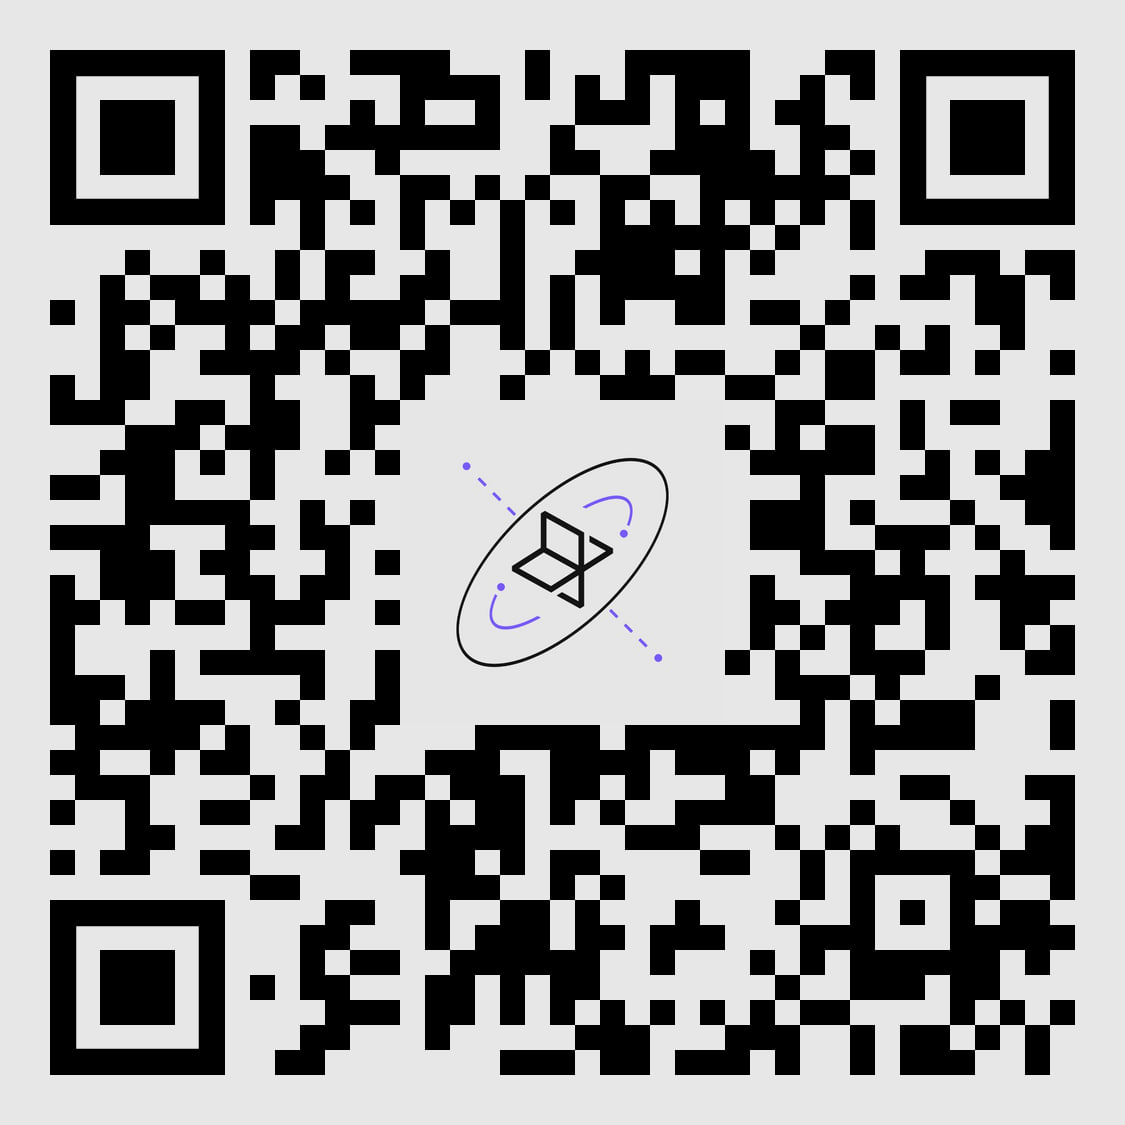